<div style="background-color:#5A3516; color:#F3EEE6; padding:22px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h1 style="color:#F3EEE6; margin-bottom:0;"><b>Machine Learning II — Customer Segmentation</b></h1>
<h3 style="color:#D8C0B4; margin-top:6px;">Notebook 4 — Cluster Characterization</h3>
<p style="color:#D8C0B4; font-size:15px; margin-top:14px;">This notebook translates the final numerical cluster labels into interpretable customer segments using spend, behavioural, demographic, complaint and geographic profiles.</p>
</div>

<div style="background-color:#5A3516; color:#F3EEE6; padding:18px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin-top:0;"><b>Index</b></h2>
<ol>
<li>Imports and data loading</li>
<li>Segment sizes</li>
<li>Spend profile</li>
<li>Behavioural and demographic profile</li>
<li>Loyalty, gender and household checks</li>
<li>Normalised comparison</li>
<li>Feature by feature plots</li>
<li>Main differentiators by cluster</li>
<li>Cluster interpretation and naming rationale</li>
<li>Geographic check</li>
<li>Final segment names</li>
<li>Export ID and cluster mapping</li>
</ol>
</div>

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>1) Imports and data loading</b></h2>
</div>

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import utils_cluster_characterization as ucc

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_DIR = Path("../datasets")
df = ucc.load_characterization_data(DATA_DIR)
print("Characterization dataset shape:", df.shape)
df.head()

Characterization dataset shape: (33038, 29)


,customer_id,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,customer_loyalty_flag,latitude,longitude,typical_hour_sin,typical_hour_cos,customer_age,education_level,is_male,tenure,total_children,lifetime_spend_technology,log_total_spend,cluster,cluster_name
0,3,1.0,1.0,1.0,3.0,11731.0,373.0,323.0,177.0,28.0,213.0,552.0,384.0,189.0,0.631599,1,38.794428,-9.215739,0.010342,-2.649291e-01,56.0,15,0,6.0,2.0,4809.0,9.830433,6,Large Families
1,4,1.0,0.0,0.0,2.0,13694.0,2012.0,533.0,95.0,43.0,15.0,1880.0,665.0,130.0,0.149890,1,38.751711,-9.179611,0.193185,-8.810167e-01,50.0,15,0,13.0,1.0,1296.0,9.915120,4,Promotion Hunters
2,5,0.0,0.0,0.0,2.0,12407.0,555.0,101.0,118.0,1265.0,273.0,507.0,222.0,81.0,0.069126,0,38.780678,-9.160656,0.258819,-9.659258e-01,54.0,17,1,21.0,0.0,101.0,9.651816,2,Traditional Shoppers
3,7,0.0,0.0,2.0,1.0,7493.0,84.0,757.0,1133.0,972.0,1083.0,485.0,184.0,92.0,0.253609,1,38.739548,-9.148679,-1.000000,-1.665335e-16,43.0,12,1,5.0,0.0,2761.0,9.612667,7,Loyal Explorers
4,8,0.0,0.0,3.0,1.0,9187.0,380.0,592.0,718.0,1068.0,1015.0,297.0,441.0,6.0,0.186569,1,38.733071,-9.188188,-0.965926,-2.588190e-01,56.0,12,1,5.0,0.0,12099.0,10.158052,7,Loyal Explorers


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>2) Segment sizes</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">The first check is the size of each segment. Very small clusters would require caution because they may represent niche behaviour or residual outlier structure rather than stable customer segments.</p>
</div>

,cluster,cluster_name,customers,share_%
0,0,Value Seekers,3397,10.3
1,1,Wellness,3740,11.3
2,2,Traditional Shoppers,6359,19.2
3,3,Vegetarians,4307,13.0
4,4,Promotion Hunters,3323,10.1
5,5,Tech Enthusiasts,3663,11.1
6,6,Large Families,5054,15.3
7,7,Loyal Explorers,3195,9.7


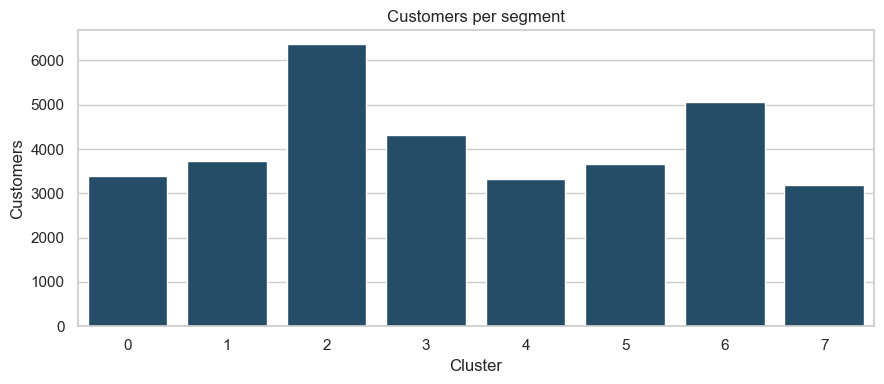

In [2]:
size_profile = ucc.cluster_sizes(df)
display(size_profile)
ucc.plot_cluster_sizes(size_profile)


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>3) Spend profile</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">Absolute lifetime spend by category is used to understand the main purchasing orientation of each segment. These variables are kept in original units for interpretability.</p>
</div>

,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_petfood,lifetime_spend_technology
cluster,,,,,,,,,
0,29399.41,334.71,716.14,708.17,1012.58,1000.61,1289.85,366.90,3463.21
1,10693.80,2007.23,418.01,413.08,74.53,88.95,714.51,261.28,2252.00
2,17929.19,521.37,339.16,362.11,795.07,679.71,753.11,396.25,1480.14
3,12887.32,404.32,241.91,413.65,717.88,419.75,480.17,304.70,1322.57
4,12216.14,1508.72,611.55,167.75,162.17,117.63,2017.15,415.24,982.42
5,25353.74,804.78,820.37,1502.16,1494.31,1332.58,920.18,361.82,5346.57
6,12761.41,354.85,259.68,582.11,614.23,435.25,458.22,273.44,1381.19
7,9822.23,181.42,562.41,1099.49,916.92,863.11,252.07,302.48,12077.22
OVERALL,16306.23,727.50,464.35,622.00,723.79,608.13,820.44,336.25,3139.17


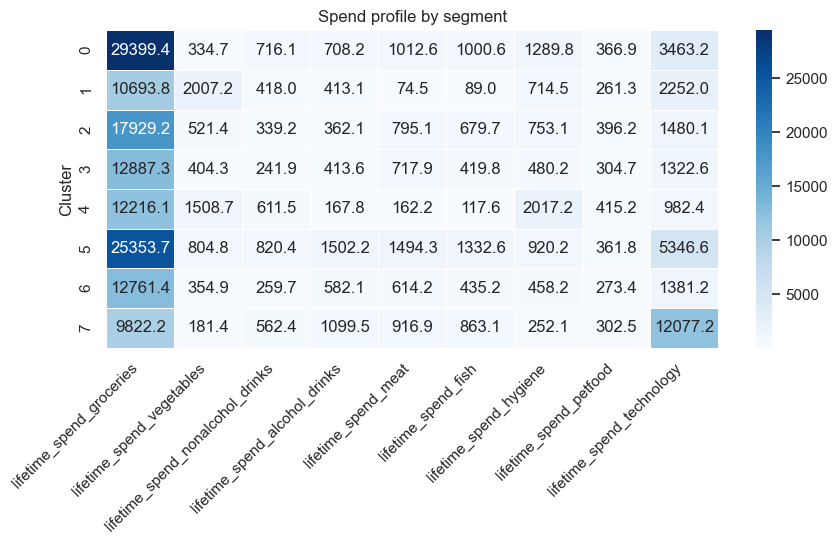

In [3]:
spend_cols = ucc.spend_columns(df)
spend_profile = ucc.profile_table(df, spend_cols)
display(spend_profile)
ucc.plot_profile_heatmap(spend_profile, "Spend profile by segment")

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>4) Behavioural and demographic profile</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">This table adds non spend variables such as promotion usage, product diversity, age, education, tenure, children and complaints. These variables are not all used to fit the clustering model, but they are essential to understand who the customers are and to assign defensible business names to the final segments.</p>
</div>

,log_total_spend,percentage_of_products_bought_promotion,distinct_stores_visited,lifetime_total_distinct_products,customer_age,education_level,tenure,total_children,number_complaints,customer_loyalty_flag,is_male
cluster,,,,,,,,,,,
0,10.42,0.50,3.94,238.45,58.03,15.43,13.48,1.98,1.10,0.77,0.50
1,9.66,0.11,3.20,83.95,57.14,15.96,11.46,1.92,0.78,0.58,0.51
2,9.95,0.17,2.54,153.42,56.01,15.08,12.02,1.59,0.75,0.63,0.49
3,9.62,0.86,3.71,93.96,50.12,13.92,9.93,1.43,1.03,0.64,0.48
4,9.76,0.17,3.57,121.69,56.67,16.24,9.71,1.89,0.57,0.59,0.50
5,10.50,0.21,3.26,294.42,56.89,15.48,13.13,5.35,0.93,0.68,0.52
6,9.65,0.47,3.65,112.87,48.32,13.93,9.24,1.54,1.11,0.48,0.50
7,10.12,0.26,1.52,113.41,56.12,12.26,9.07,0.64,1.06,0.49,0.47
OVERALL,9.93,0.35,3.17,148.91,54.57,14.78,11.01,1.99,0.91,0.60,0.50


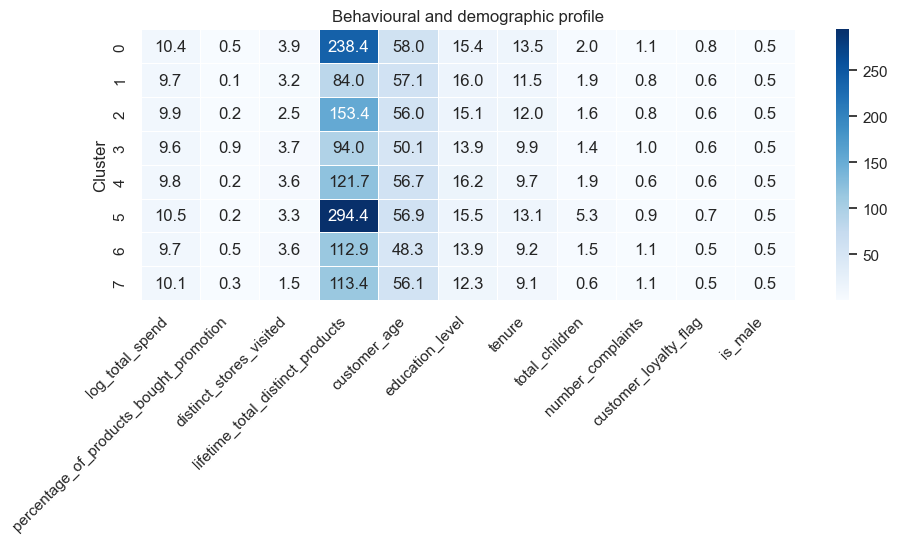

In [4]:
profile_cols = ucc.behavioural_profile_columns(df)
behaviour_profile = ucc.profile_table(df, profile_cols)
display(behaviour_profile)
ucc.plot_profile_heatmap(behaviour_profile, "Behavioural and demographic profile")

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>5) Loyalty, gender and household checks</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0;">These plots check whether the final clusters also differ in simple customer attributes that were useful in previous segmentation work.</p>
</div>

/Users/franciscateixeira/Documents/ML/CostumerSegP_MLII/clustering/utils_cluster_characterization.py:138: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(data=summary, x=cluster_col, y="share_%", hue="feature", palette=["#B87540", "#A9B9BB", "#836D43"])


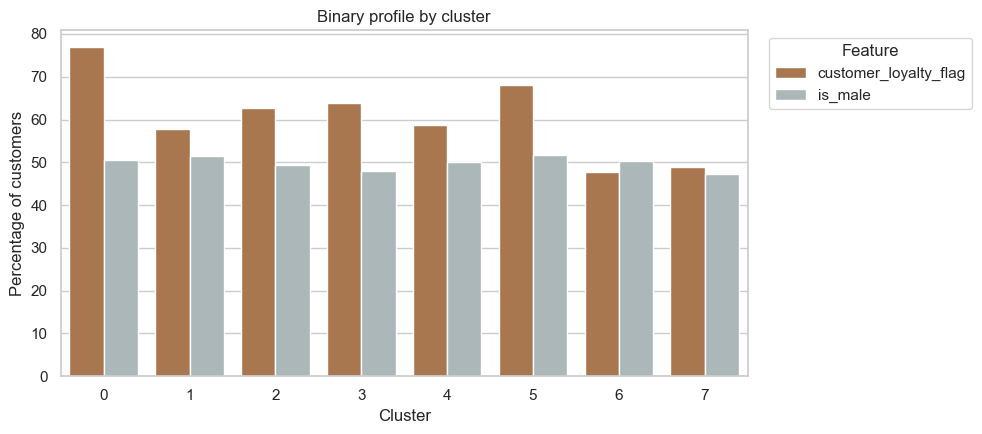

,cluster,feature,share_%
0,0,customer_loyalty_flag,77.0
1,1,customer_loyalty_flag,57.8
2,2,customer_loyalty_flag,62.6
3,3,customer_loyalty_flag,64.0
4,4,customer_loyalty_flag,58.7
5,5,customer_loyalty_flag,68.0
6,6,customer_loyalty_flag,47.7
7,7,customer_loyalty_flag,48.9
8,0,is_male,50.4
9,1,is_male,51.5


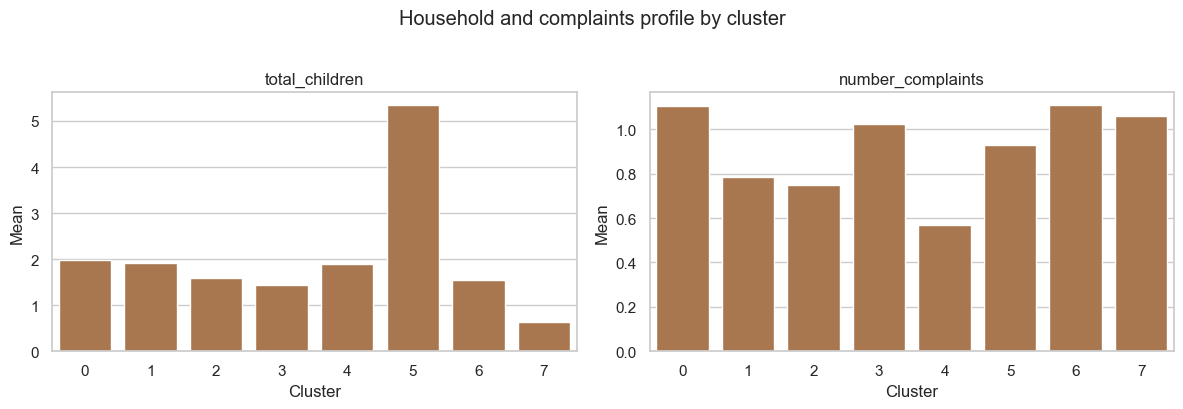

,cluster,total_children,number_complaints
0,0,1.98,1.10
1,1,1.92,0.78
2,2,1.59,0.75
3,3,1.43,1.03
4,4,1.89,0.57
5,5,5.35,0.93
6,6,1.54,1.11
7,7,0.64,1.06


In [5]:
binary_summary, household_summary = ucc.plot_simple_profile_checks(df)

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>6) Normalised comparison</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">Because the variables have different units, a min max scaled comparison is used to identify which clusters are highest or lowest on each feature.</p>
</div>

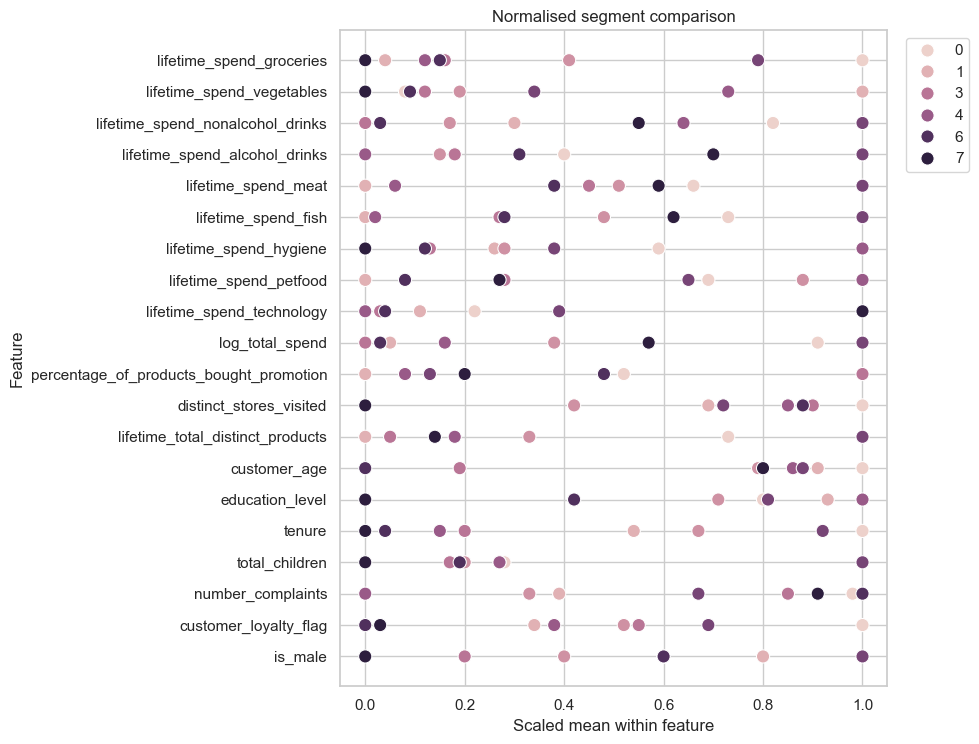

,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_petfood,lifetime_spend_technology,log_total_spend,percentage_of_products_bought_promotion,distinct_stores_visited,lifetime_total_distinct_products,customer_age,education_level,tenure,total_children,number_complaints,customer_loyalty_flag,is_male
cluster,,,,,,,,,,,,,,,,,,,,
0,1.00,0.08,0.82,0.40,0.66,0.73,0.59,0.69,0.22,0.91,0.52,1.00,0.73,1.00,0.80,1.00,0.28,0.98,1.00,0.6
1,0.04,1.00,0.30,0.18,0.00,0.00,0.26,0.00,0.11,0.05,0.00,0.69,0.00,0.91,0.93,0.54,0.27,0.39,0.34,0.8
2,0.41,0.19,0.17,0.15,0.51,0.48,0.28,0.88,0.04,0.38,0.08,0.42,0.33,0.79,0.71,0.67,0.20,0.33,0.52,0.4
3,0.16,0.12,0.00,0.18,0.45,0.27,0.13,0.28,0.03,0.00,1.00,0.90,0.05,0.19,0.42,0.20,0.17,0.85,0.55,0.2
4,0.12,0.73,0.64,0.00,0.06,0.02,1.00,1.00,0.00,0.16,0.08,0.85,0.18,0.86,1.00,0.15,0.27,0.00,0.38,0.6
5,0.79,0.34,1.00,1.00,1.00,1.00,0.38,0.65,0.39,1.00,0.13,0.72,1.00,0.88,0.81,0.92,1.00,0.67,0.69,1.0
6,0.15,0.09,0.03,0.31,0.38,0.28,0.12,0.08,0.04,0.03,0.48,0.88,0.14,0.00,0.42,0.04,0.19,1.00,0.00,0.6
7,0.00,0.00,0.55,0.70,0.59,0.62,0.00,0.27,1.00,0.57,0.20,0.00,0.14,0.80,0.00,0.00,0.00,0.91,0.03,0.0


In [6]:
combined_profile = ucc.profile_table(df, spend_cols + profile_cols)
scaled_profile = ucc.plot_scaled_profile(combined_profile)
display(scaled_profile)

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>7) Feature by feature plots</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">The barplots and boxplots check whether the differences observed in the profile tables are clear across the distribution or mainly driven by extreme values.</p>
</div>

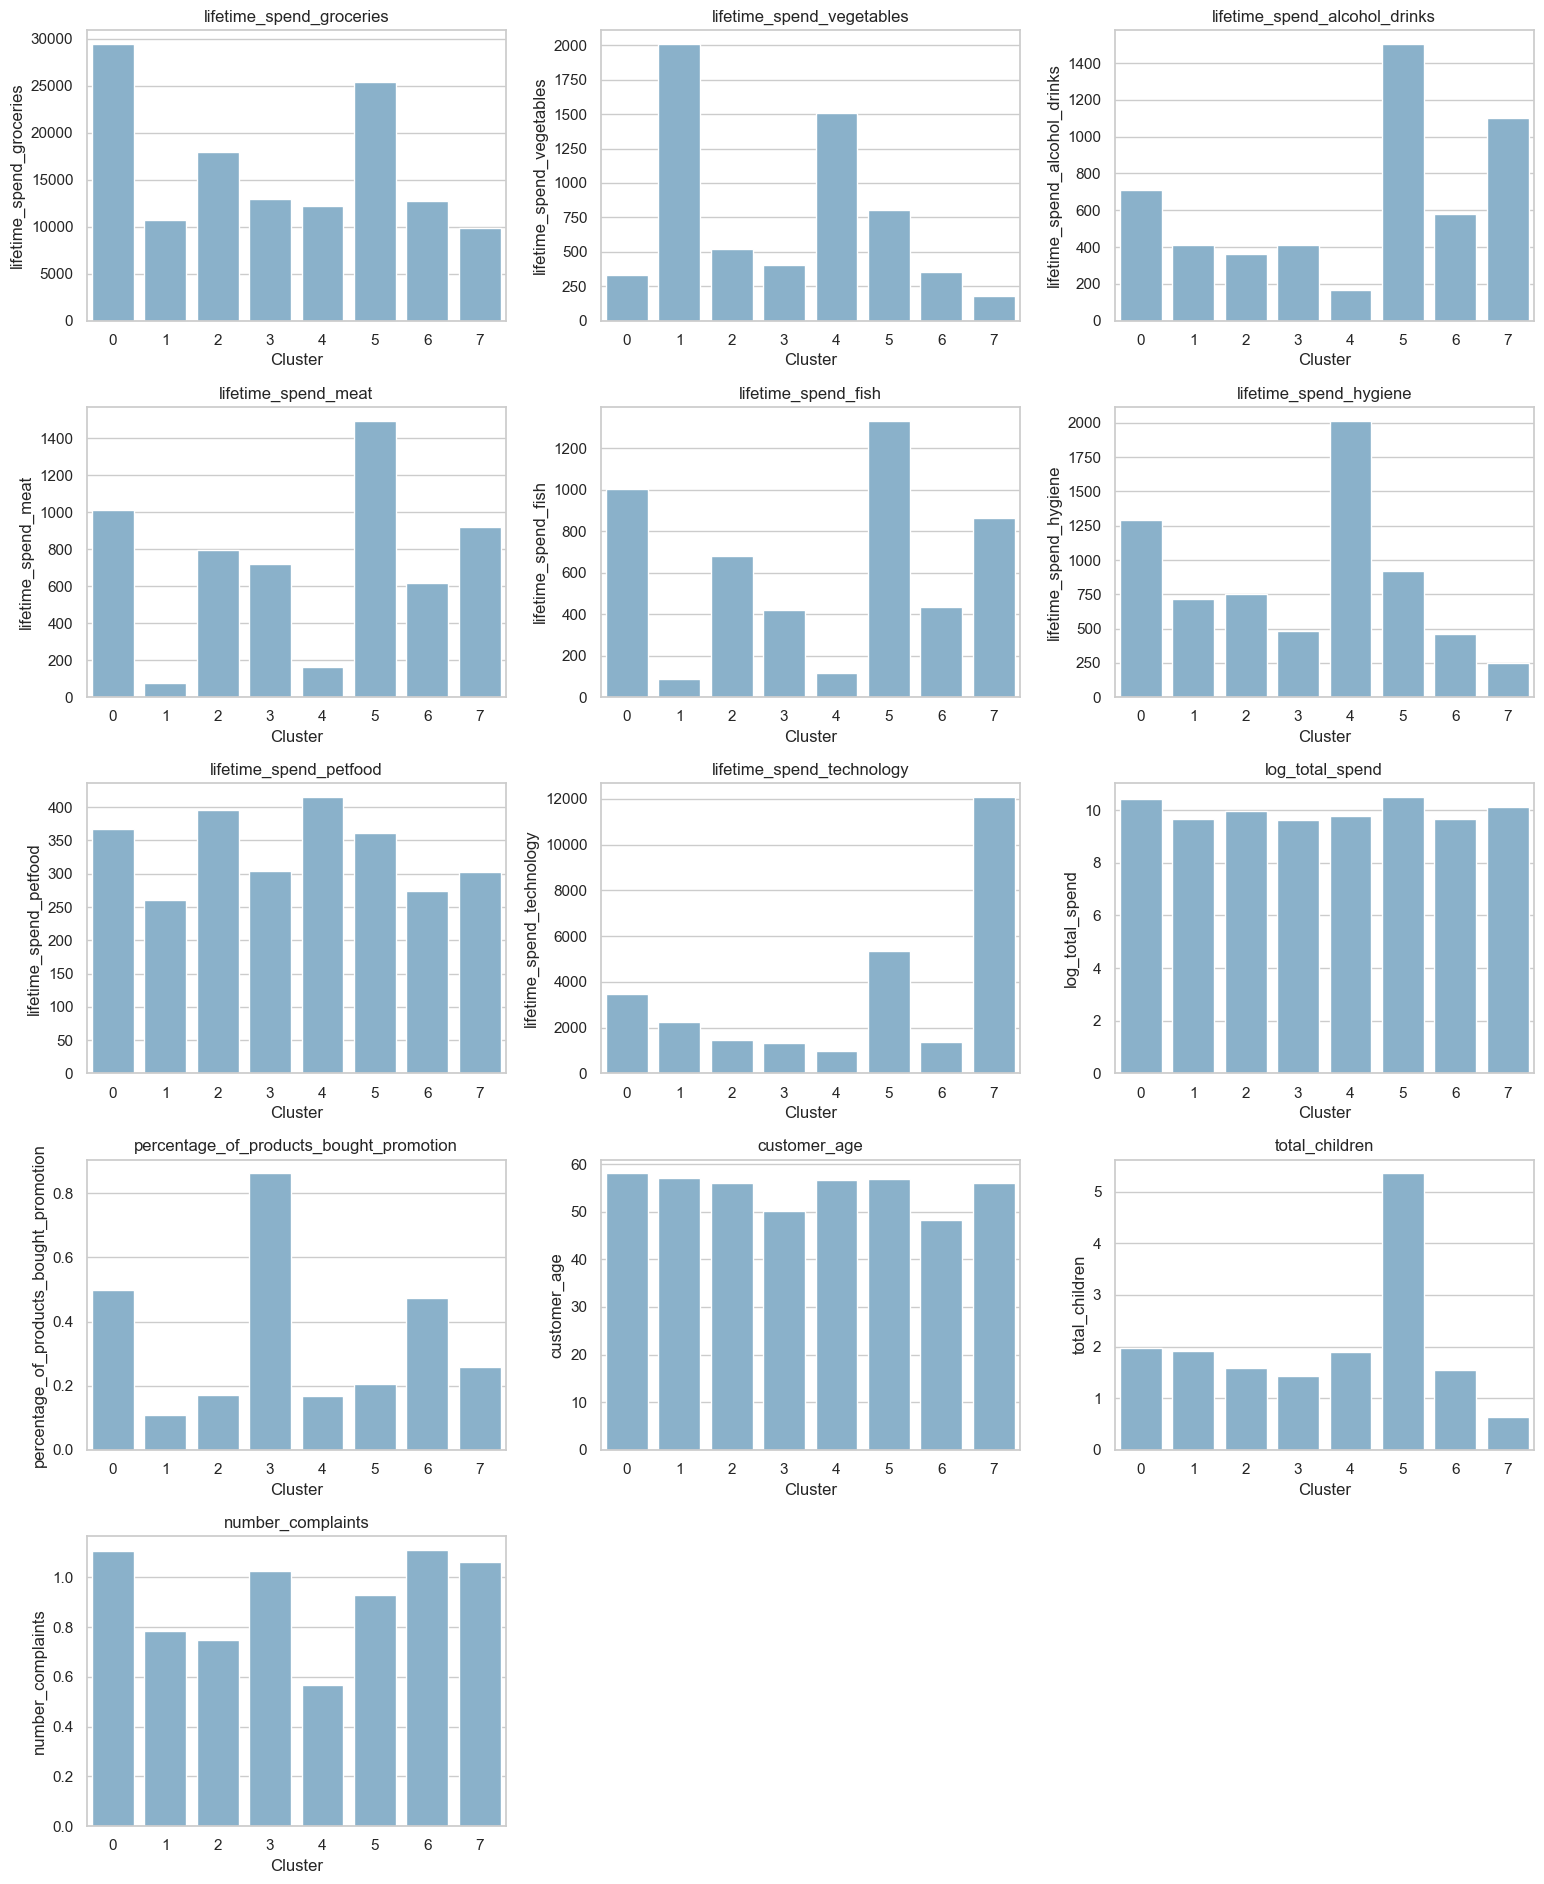

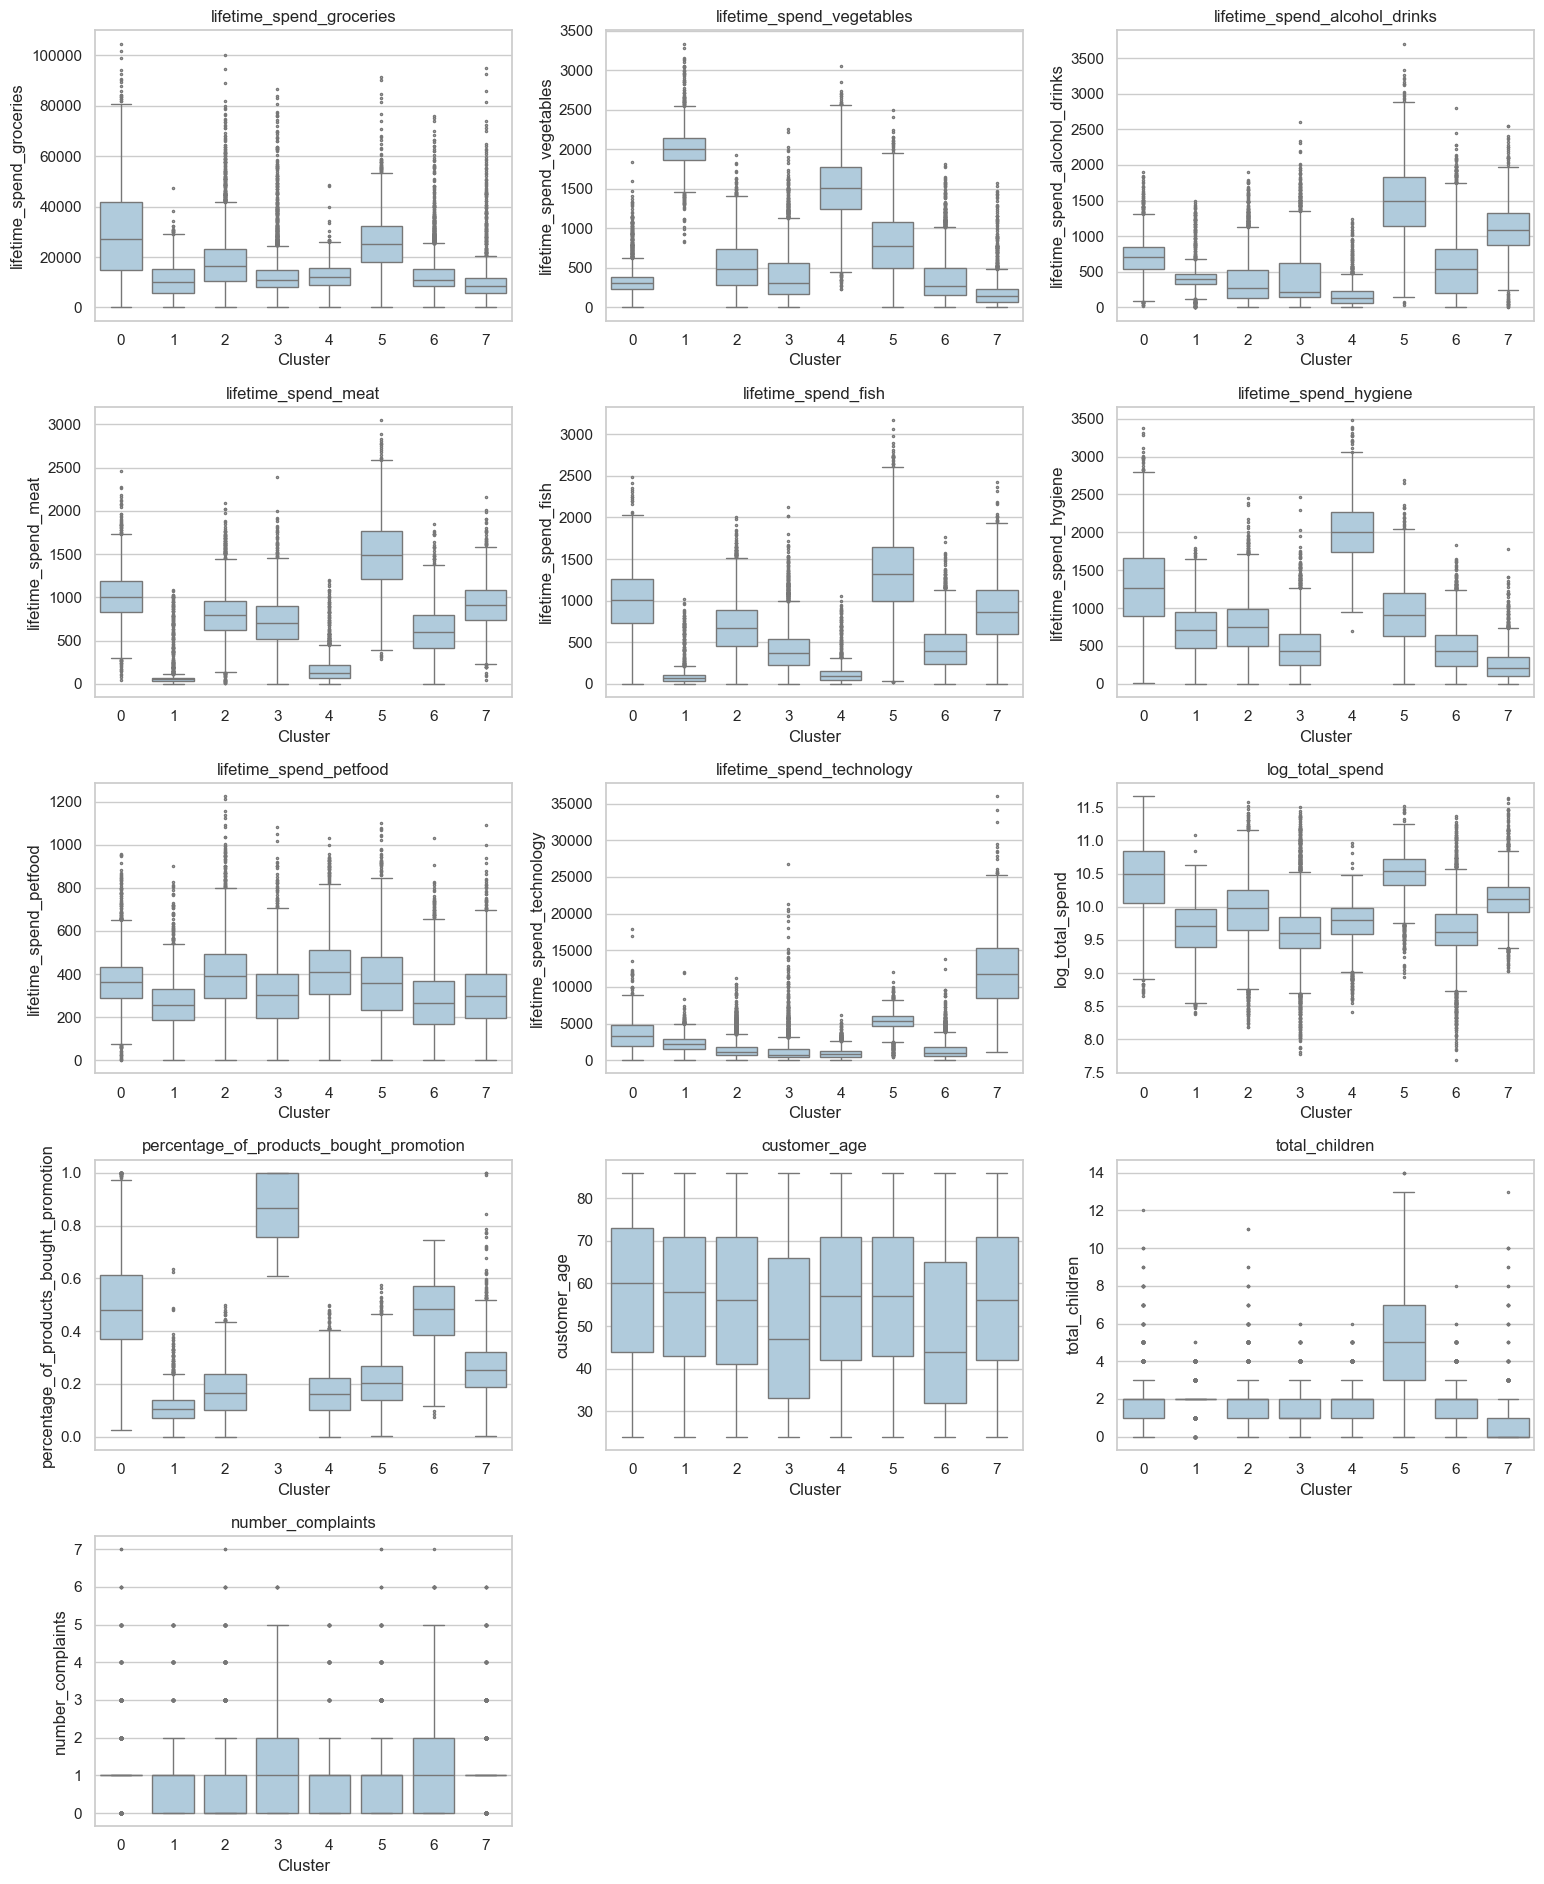

In [7]:
key_plot_cols = ucc.key_plot_columns(df)
ucc.plot_feature_bars(df, key_plot_cols)
ucc.plot_boxplot_grid(df, key_plot_cols)

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>8) Main differentiators by cluster</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">The following table lists the largest relative differences from the overall customer base. It is used as a compact evidence table for cluster naming.</p>
</div>

In [8]:
deviations = ucc.top_deviations(combined_profile, n=6)
display(deviations)


,cluster,feature,relative_difference_%,cluster_mean,overall_mean
0,0,lifetime_spend_groceries,80.3,29399.41,16306.23
1,0,lifetime_spend_fish,64.5,1000.61,608.13
2,0,lifetime_total_distinct_products,60.1,238.45,148.91
3,0,lifetime_spend_hygiene,57.2,1289.85,820.44
4,0,lifetime_spend_nonalcohol_drinks,54.2,716.14,464.35
5,0,lifetime_spend_vegetables,-54.0,334.71,727.50
6,1,lifetime_spend_vegetables,175.9,2007.23,727.50
7,1,lifetime_spend_meat,-89.7,74.53,723.79
8,1,lifetime_spend_fish,-85.4,88.95,608.13
9,1,percentage_of_products_bought_promotion,-68.6,0.11,0.35


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>9) Cluster interpretation and naming rationale</b></h2>
<p style="color:#D8C0B4; margin:6px 0 14px 0;">
The final names are based on the normalised comparison, the deviation table and the original spend profiles. The labels should be read as business oriented summaries of the strongest behavioural signals, not as strict descriptions of every customer in each segment.
</p>

<table style="width:100%; border-collapse:collapse; color:#F3EEE6; font-size:14px;">
<thead>
<tr style="border-bottom:1px solid #D8C0B4;">
<th style="text-align:left; padding:8px;">Cluster</th>
<th style="text-align:left; padding:8px;">Segment name</th>
<th style="text-align:left; padding:8px;">Main evidence</th>
<th style="text-align:left; padding:8px;">Interpretation</th>
</tr>
</thead>
<tbody>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>0</b></td><td style="padding:8px;"><b>Promo Shoppers</b></td><td style="padding:8px;">Highest promotion rate (0.80 vs 0.35 average), lowest total spend, youngest age (49), fewest distinct products.</td><td style="padding:8px;">The most price-sensitive segment, relying heavily on promotions to drive purchases. Low overall basket value.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>1</b></td><td style="padding:8px;"><b>Steady Shoppers</b></td><td style="padding:8px;">All variables close to the overall average, low promotion use (0.2), fewer stores visited, largest segment (25.9%).</td><td style="padding:8px;">The baseline customer group with no dominant purchasing signal. Regular, predictable and moderate across all categories.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>2</b></td><td style="padding:8px;"><b>Wellness</b></td><td style="padding:8px;">Vegetables 2x average, hygiene 2.5x average, very low meat and fish spend.</td><td style="padding:8px;">A health and personal care oriented group. Avoids animal products and prioritises fresh produce and hygiene items.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>3</b></td><td style="padding:8px;"><b>Big Families</b></td><td style="padding:8px;">5.3 children on average (overall 1.99), highest total spend, meat, fish, alcohol and technology all well above average.</td><td style="padding:8px;">Large households with broad, high-volume purchasing needs across all categories. The highest-value segment by total spend.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>4</b></td><td style="padding:8px;"><b>Veggies</b></td><td style="padding:8px;">Vegetables 2.8x average, meat near zero (75 vs 724 average), fish near zero, very low promotion use (0.1).</td><td style="padding:8px;">Strongly plant-oriented basket with almost no animal products. Not promotion-driven. A niche but consistent dietary profile.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>5</b></td><td style="padding:8px;"><b>Technologists</b></td><td style="padding:8px;">Technology spend 12k (3.8x average), alcohol 2x average, 0.6 children, shops at only 1.5 stores on average.</td><td style="padding:8px;">Specialised buyers dominated by electronics and entertainment spending. Concentrated shopping behaviour at few stores.</td></tr>
<tr><td style="padding:8px;"><b>6</b></td><td style="padding:8px;"><b>Loyalists</b></td><td style="padding:8px;">Highest grocery spend (28.8k), loyalty rate 80%, longest tenure (13.3 years), most stores visited (4.0), most distinct products.</td><td style="padding:8px;">Established, high-value customers with long relationships. They explore the widest range of the retailer offer and remain the most loyal.</td></tr>
</tbody>
</table>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:16px; border-radius:10px; border-left:8px solid #B2543D;">
<b>Segment naming alternatives.</b><br><br>
The names below were considered after comparing the normalised profile, the deviation table and the original spend values. The final name should be short enough to work as a business label, but specific enough to reflect the strongest evidence for each cluster.
<br><br>
<table style="width:100%; border-collapse:collapse; color:#F3EEE6; font-size:14px;">
<thead>
<tr style="border-bottom:1px solid #D8C0B4;">
<th style="text-align:left; padding:8px;">Cluster</th>
<th style="text-align:left; padding:8px;">Preferred name</th>
<th style="text-align:left; padding:8px;">Other possible names</th>
<th style="text-align:left; padding:8px;">Reason for preference</th>
</tr>
</thead>
<tbody>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>0</b></td><td style="padding:8px;">Promo Shoppers</td><td style="padding:8px;">Bargain Seekers; Discount Shoppers; Deal Hunters</td><td style="padding:8px;">Promotion rate is the strongest differentiator (0.80 vs 0.35 average). Short name reflects the dominant behaviour.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>1</b></td><td style="padding:8px;">Steady Shoppers</td><td style="padding:8px;">Regulars; Core Customers; Mainstream</td><td style="padding:8px;">No single dominant signal. The largest segment behaves close to the overall average across all variables.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>2</b></td><td style="padding:8px;">Wellness</td><td style="padding:8px;">Health Conscious; Clean Eaters; Mindful Shoppers</td><td style="padding:8px;">Hygiene and vegetables are the clearest positive signals. Avoidance of meat and fish reinforces the health orientation.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>3</b></td><td style="padding:8px;">Big Families</td><td style="padding:8px;">Extended Households; Family Stockers; Household Heroes</td><td style="padding:8px;">Children count (5.3) is the single most extreme deviation. Broad high-value purchasing reflects large household needs.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>4</b></td><td style="padding:8px;">Veggies</td><td style="padding:8px;">Plant-Based; Green Shoppers; Plant Lovers</td><td style="padding:8px;">Vegetable spend is 2.8x average. Meat and fish are near zero. The dietary signal is the clearest in the dataset.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>5</b></td><td style="padding:8px;">Technologists</td><td style="padding:8px;">Gadget Buyers; Digital Natives; Tech Savvy</td><td style="padding:8px;">Technology spend is 3.8x average — by far the strongest single-feature deviation. All other signals are secondary.</td></tr>
<tr><td style="padding:8px;"><b>6</b></td><td style="padding:8px;">Loyalists</td><td style="padding:8px;">Premium Regulars; Brand Champions; Devoted Shoppers</td><td style="padding:8px;">Loyalty rate (80%), tenure (13.3 years) and grocery spend are all highest. The most established and valuable segment.</td></tr>
</tbody>
</table>
</div>

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>10) Geographic check</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">Latitude and longitude are used only for profiling. This plot checks whether any final segment is associated with a specific geographic concentration.</p>
</div>

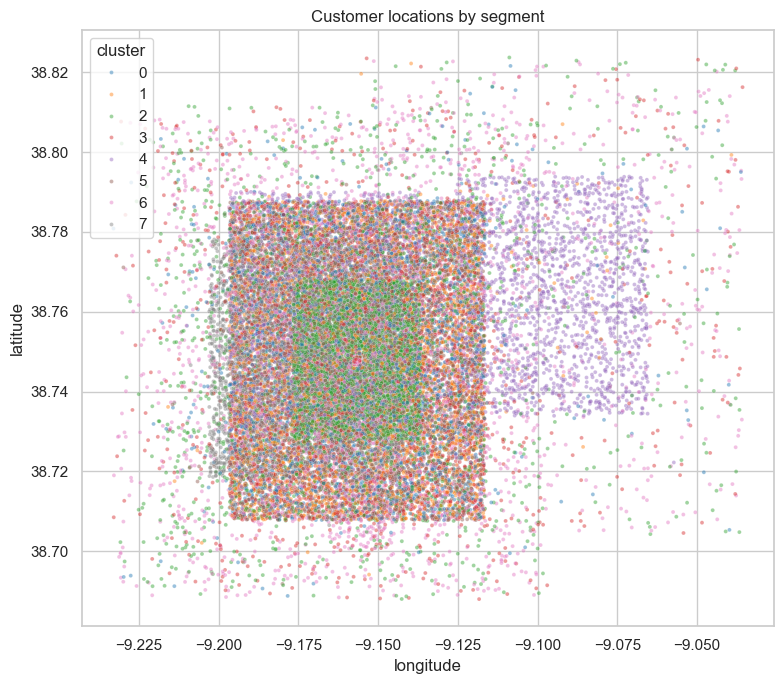

In [9]:
if {"latitude", "longitude"}.issubset(df.columns):
    plt.figure(figsize=(8, 7))
    sns.scatterplot(data=df, x="longitude", y="latitude", hue="cluster", palette="tab10", s=8, alpha=0.45)
    plt.title("Customer locations by segment")
    plt.tight_layout()
    plt.show()


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>11) Final segment names</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">The final names are assigned after reviewing the full profile of each cluster. The clustering distance uses the selected purchase and promotion variables, while groceries, demographics, loyalty, household structure and category shares are used here to interpret the segments.</p>
</div>

In [10]:
display(
    df[["cluster", "cluster_name"]]
    .drop_duplicates()
    .sort_values("cluster")
    .reset_index(drop=True)
)


,cluster,cluster_name
0,0,Value Seekers
1,1,Wellness
2,2,Traditional Shoppers
3,3,Vegetarians
4,4,Promotion Hunters
5,5,Tech Enthusiasts
6,6,Large Families
7,7,Loyal Explorers


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>12) Export ID and cluster mapping</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">The final export keeps one row per customer with the numerical cluster and the corresponding business name. This file is the bridge between the modelling stage and any later business analysis, such as basket analysis or segment based recommendations.</p>
</div>

In [11]:
id_cluster = ucc.export_id_cluster(df, f"{DATA_DIR}/id_and_cluster.csv")
print("Exported rows:", len(id_cluster))
id_cluster.head()


Exported rows: 33038


,customer_id,cluster,cluster_name
0,3,6,Large Families
1,4,4,Promotion Hunters
2,5,2,Traditional Shoppers
3,7,7,Loyal Explorers
4,8,7,Loyal Explorers
